In [8]:
import sys
import os
import numpy as np

sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"..")))

from modules.seismo_response.class_hh_calibration import HH_Calibration
from modules.seismo_response.class_Vs_profile import Vs_Profile
from modules.seismo_response.class_curves import Multiple_GGmax_Damping_Curves
from libs.config.config_variables import STORAGE_DIR

In [6]:
sesion = "sesion_20260223_103200_ew"
vs_input = STORAGE_DIR / "raw_data" / sesion / "vs_profile.txt"
dynamic_curves = STORAGE_DIR / "raw_data" / sesion / "dynamic_curves.txt"

In [9]:
curvas_dinamicas = Multiple_GGmax_Damping_Curves(data=str(dynamic_curves))

In [18]:
mgc, mdc = curvas_dinamicas.get_MGC_MDC_objects()

In [19]:
mgc

n_layers = 2, type: <class 'modules.seismo_response.class_curves.GGmax_Curve'>

In [3]:
profile = Vs_Profile(data=str(vs_input))

In [29]:
tau_max = np.array([120000,200000])

In [30]:
profile_calibration = HH_Calibration(vs_profile = profile, GGmax_curves=mgc, Tmax_profile=tau_max)

------ G/Gmax provided; fitting MKZ curves to data: ------
****** MKZ parameters: ******
Layer 0: gamma_ref = 0.000408, s = 0.838, beta = 1.73
Layer 1: gamma_ref = 0.000885, s = 0.838, beta = 1.66


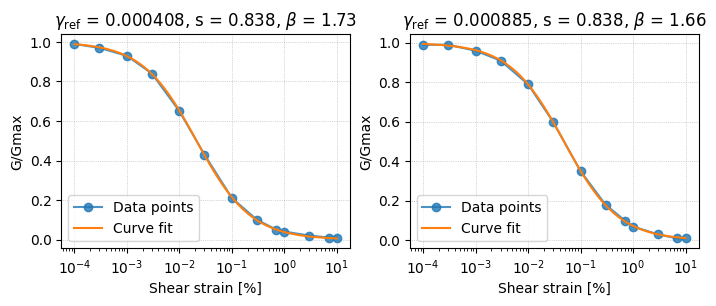

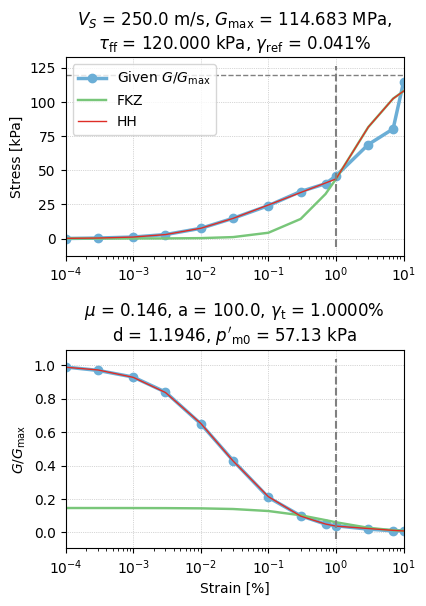

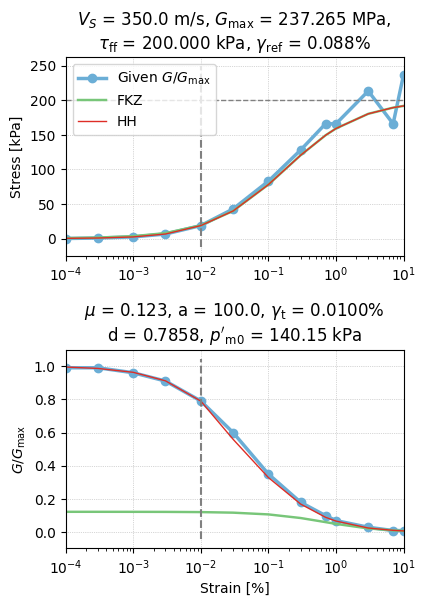

In [31]:
profile_calibration.fit(show_fig=True)